# Importing all libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

In [3]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

In [4]:
from sklearn.pipeline import Pipeline

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Data cleaning

In [6]:
df = pd.read_csv(
    r"/home/shanta-majumder/DS_env/Dataset/blood_samples_dataset_test.csv")

In [7]:
df.head(10)

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,0.001827,0.033693,0.114755,0.997927,0.562604,0.866499,0.578042,0.914615,0.026864,0.038641,...,0.653230,0.186104,0.430398,0.016678,0.885352,0.652733,0.788235,0.054788,0.031313,Thalasse
1,0.436679,0.972653,0.084998,0.180909,0.675736,0.563889,0.798382,0.670361,0.376092,0.184890,...,0.833540,0.153001,0.458533,0.401845,0.635969,0.574425,0.047025,0.607985,0.594123,Diabetes
2,0.545697,0.324815,0.584467,0.475748,0.558596,0.661007,0.934056,0.381782,0.500342,0.531829,...,0.678901,0.220479,0.817151,0.690981,0.101633,0.855740,0.551124,0.413294,0.070909,Heart Di
3,0.172994,0.050351,0.736000,0.782022,0.069435,0.085219,0.032907,0.460619,0.785448,0.491495,...,0.381500,0.459396,0.420154,0.798537,0.399236,0.324600,0.499504,0.436662,0.242766,Diabetes
4,0.758534,0.739968,0.597868,0.772683,0.875720,0.860265,0.486189,0.486686,0.621048,0.191756,...,0.993381,0.272338,0.663579,0.265227,0.918847,0.804910,0.571119,0.188368,0.750848,Heart Di
5,0.321872,0.554649,0.195652,0.427216,0.807751,0.376964,0.519526,0.028090,0.382538,0.568205,...,0.711377,0.887863,0.370344,0.607066,0.936445,0.160355,0.108994,0.599071,0.560535,Heart Di
6,0.677636,0.435037,0.572571,0.965847,0.010580,0.753719,0.262138,0.789804,0.541149,0.550569,...,0.196416,0.141203,0.355437,0.468168,0.493548,0.213971,0.059427,0.836447,0.231356,Diabetes
7,0.105103,0.177558,0.169041,0.679138,0.886839,0.714977,0.197501,0.778653,0.319864,0.285914,...,0.259719,0.305473,0.867800,0.213141,0.094877,0.120487,0.211855,0.376829,0.645990,Diabetes
8,0.186686,0.210425,0.165662,0.207388,0.918350,0.746808,0.230674,0.616086,0.533183,0.400058,...,0.600902,0.812273,0.332766,0.797290,0.190961,0.298596,0.877684,0.966106,0.306355,Heart Di
9,0.448025,0.974133,0.143226,0.471179,0.161697,0.610458,0.470737,0.275112,0.702463,0.423561,...,0.435143,0.934164,0.094991,0.795212,0.456302,0.122741,0.820810,0.045505,0.562205,Diabetes


In [8]:
df.isnull()

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
482,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
483,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
484,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
df = df.dropna()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 486 entries, 0 to 485
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Glucose                                    486 non-null    float64
 1   Cholesterol                                486 non-null    float64
 2   Hemoglobin                                 486 non-null    float64
 3   Platelets                                  486 non-null    float64
 4   White Blood Cells                          486 non-null    float64
 5   Red Blood Cells                            486 non-null    float64
 6   Hematocrit                                 486 non-null    float64
 7   Mean Corpuscular Volume                    486 non-null    float64
 8   Mean Corpuscular Hemoglobin                486 non-null    float64
 9   Mean Corpuscular Hemoglobin Concentration  486 non-null    float64
 10  Insulin                   

In [11]:
df.describe()

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,Triglycerides,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein
count,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,...,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000
mean,0.490044,0.506797,0.485502,0.528136,0.509783,0.504347,0.501042,0.516185,0.510145,0.501105,...,0.498538,0.489365,0.501706,0.487933,0.500615,0.499675,0.493794,0.515541,0.510077,0.517365
std,0.284196,0.282871,0.298818,0.292610,0.290887,0.302865,0.294501,0.279954,0.285213,0.290614,...,0.288848,0.290849,0.286729,0.292726,0.285374,0.301451,0.292400,0.287223,0.294011,0.291645
min,0.001827,0.003088,0.000719,0.000006,-0.000206,0.000552,0.004556,0.000309,-0.000614,0.000719,...,0.001885,-0.000991,0.001036,-0.000546,-0.000312,0.002047,0.002145,0.008831,0.005714,-0.000991
25%,0.236664,0.268021,0.201994,0.276155,0.264944,0.218573,0.246255,0.287755,0.259967,0.255839,...,0.238772,0.239302,0.262516,0.229095,0.251076,0.239369,0.228581,0.262924,0.267101,0.263192
50%,0.496471,0.502397,0.477706,0.538642,0.511102,0.518103,0.496275,0.533319,0.498332,0.493929,...,0.503164,0.481549,0.511373,0.481533,0.515321,0.497846,0.507581,0.526299,0.508479,0.546542
75%,0.727144,0.754638,0.750028,0.789486,0.767896,0.768466,0.761107,0.746765,0.761956,0.734817,...,0.749527,0.725472,0.756136,0.741867,0.739248,0.775458,0.751124,0.777839,0.781128,0.776940
max,0.991742,0.999606,0.997876,0.999507,0.999646,0.997267,1.000857,0.996362,0.999234,0.999666,...,0.999826,0.999265,0.999567,1.000744,1.000326,1.000402,0.999857,0.999348,1.000125,0.999488


In [12]:
df.columns

Index(['Glucose', 'Cholesterol', 'Hemoglobin', 'Platelets',
       'White Blood Cells', 'Red Blood Cells', 'Hematocrit',
       'Mean Corpuscular Volume', 'Mean Corpuscular Hemoglobin',
       'Mean Corpuscular Hemoglobin Concentration', 'Insulin', 'BMI',
       'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'Triglycerides',
       'HbA1c', 'LDL Cholesterol', 'HDL Cholesterol', 'ALT', 'AST',
       'Heart Rate', 'Creatinine', 'Troponin', 'C-reactive Protein',
       'Disease'],
      dtype='object')

In [13]:
X = df.iloc[:, 0:-1]
Y = df.iloc[:, -1]

In [14]:
print(X.shape)
print(Y.shape)

(486, 24)
(486,)


In [15]:
label_encoder = LabelEncoder()
Y = label_encoder.fit_transform(Y)
print("Classes:", label_encoder.classes_)

Classes: ['Anemia' 'Diabetes' 'Healthy' 'Heart Di' 'Thalasse' 'Thromboc']


In [16]:
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, train_size=0.8, shuffle=True)

# Hyperparameter Optimization with Optuna
We will use Optuna to optimize the hyperparameters of our stacking pipeline for 20 trials.

In [72]:
import optuna
from sklearn.model_selection import cross_val_score


def objective(trial):
    gb_learning_rate = trial.suggest_categorical(
        'gb_learning_rate', [0.1, 0.0001])
    lr_C = trial.suggest_categorical('lr_C', [2.0])
    rf_n_estimators = trial.suggest_categorical(
        'rf_n_estimators', [50, 100, 150, 200])
    rf_criterion = trial.suggest_categorical('rf_criterion', ["log_loss"])
    rf_max_depth = trial.suggest_categorical('rf_max_depth', [20])
    rf_min_samples_leaf = trial.suggest_categorical(
        'rf_min_samples_leaf', [10])
    rf_min_samples_split = trial.suggest_categorical(
        'rf_min_samples_split', [4])
    rf_max_features = trial.suggest_categorical(
        'rf_max_features', ["sqrt", "log2"])

    base_model = [
        ('gb', GradientBoostingClassifier(
            loss='log_loss',
            learning_rate=gb_learning_rate
        )),
        ('lr', LogisticRegression(
            penalty='l2',
            C=lr_C
        ))
    ]
    stack = StackingClassifier(
        estimators=base_model,
        final_estimator=RandomForestClassifier(
            n_estimators=rf_n_estimators,
            criterion=rf_criterion,
            max_depth=rf_max_depth,
            min_samples_leaf=rf_min_samples_leaf,
            min_samples_split=rf_min_samples_split,
            max_features=rf_max_features
        )
    )
    pipe = Pipeline([('scaler', StandardScaler()), ('model', stack)])
    score = cross_val_score(pipe, x_train, y_train, cv=5, n_jobs=-1).mean()
    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best trial:")
print(study.best_trial)
print("Best parameters:", study.best_params)

[I 2026-08-03 13:56:33,844] A new study created in memory with name: no-name-6e818bed-0c09-4c29-8660-ca46458586a9
/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid t

Best trial:
FrozenTrial(number=9, state=<TrialState.COMPLETE: 1>, values=[0.9202131202131202], datetime_start=datetime.datetime(2026, 8, 3, 13, 57, 45, 603803), datetime_complete=datetime.datetime(2026, 8, 3, 13, 57, 54, 440977), params={'gb_learning_rate': 0.1, 'lr_C': 2.0, 'rf_n_estimators': 200, 'rf_criterion': 'log_loss', 'rf_max_depth': 20, 'rf_min_samples_leaf': 10, 'rf_min_samples_split': 4, 'rf_max_features': 'log2'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'gb_learning_rate': CategoricalDistribution(choices=(0.1, 0.0001)), 'lr_C': CategoricalDistribution(choices=(2.0,)), 'rf_n_estimators': CategoricalDistribution(choices=(50, 100, 150, 200)), 'rf_criterion': CategoricalDistribution(choices=('log_loss',)), 'rf_max_depth': CategoricalDistribution(choices=(20,)), 'rf_min_samples_leaf': CategoricalDistribution(choices=(10,)), 'rf_min_samples_split': CategoricalDistribution(choices=(4,)), 'rf_max_features': CategoricalDistribution(choices=('sqrt', 'lo

NameError: name 'optuna_pipe' is not defined

In [56]:
base_model = ([('gb', GradientBoostingClassifier()),
              ('lr', LogisticRegression())])

In [57]:
stack = StackingClassifier(estimators=base_model,
                           final_estimator=RandomForestClassifier())

In [58]:
pipe = Pipeline([('scaler', StandardScaler()), ('model', stack)])

In [59]:
parameter = {
    'model__gb__loss': ['log_loss'],
    'model__gb__learning_rate': [0.1, 0.001, 0.0001],
    'model__lr__penalty': ['l2'],
    'model__lr__C': [2.0],
    # Corrected `n_estimators`
    'model__final_estimator__n_estimators': [50, 100, 150, 200],
    'model__final_estimator__criterion': ["log_loss"],
    'model__final_estimator__max_depth': [20],
    'model__final_estimator__min_samples_leaf': [10],
    'model__final_estimator__min_samples_split': [4],
    'model__final_estimator__max_features': ["sqrt", "log2"],
}

In [60]:
random_search_cv = RandomizedSearchCV(
    pipe, param_distributions=parameter, n_iter=3, cv=5, n_jobs=-1, verbose=2, error_score='raise')

In [61]:
random_search_cv.fit(x_train, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of

[CV] END model__final_estimator__criterion=log_loss, model__final_estimator__max_depth=20, model__final_estimator__max_features=sqrt, model__final_estimator__min_samples_leaf=10, model__final_estimator__min_samples_split=4, model__final_estimator__n_estimators=50, model__gb__learning_rate=0.0001, model__gb__loss=log_loss, model__lr__C=2.0, model__lr__penalty=l2; total time=  12.5s
[CV] END model__final_estimator__criterion=log_loss, model__final_estimator__max_depth=20, model__final_estimator__max_features=sqrt, model__final_estimator__min_samples_leaf=10, model__final_estimator__min_samples_split=4, model__final_estimator__n_estimators=50, model__gb__learning_rate=0.0001, model__gb__loss=log_loss, model__lr__C=2.0, model__lr__penalty=l2; total time=  12.6s


/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of

[CV] END model__final_estimator__criterion=log_loss, model__final_estimator__max_depth=20, model__final_estimator__max_features=sqrt, model__final_estimator__min_samples_leaf=10, model__final_estimator__min_samples_split=4, model__final_estimator__n_estimators=50, model__gb__learning_rate=0.0001, model__gb__loss=log_loss, model__lr__C=2.0, model__lr__penalty=l2; total time=  12.8s
[CV] END model__final_estimator__criterion=log_loss, model__final_estimator__max_depth=20, model__final_estimator__max_features=sqrt, model__final_estimator__min_samples_leaf=10, model__final_estimator__min_samples_split=4, model__final_estimator__n_estimators=50, model__gb__learning_rate=0.1, model__gb__loss=log_loss, model__lr__C=2.0, model__lr__penalty=l2; total time=  13.0s
[CV] END model__final_estimator__criterion=log_loss, model__final_estimator__max_depth=20, model__final_estimator__max_features=sqrt, model__final_estimator__min_samples_leaf=10, model__final_estimator__min_samples_split=4, model__fina

/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403:

[CV] END model__final_estimator__criterion=log_loss, model__final_estimator__max_depth=20, model__final_estimator__max_features=sqrt, model__final_estimator__min_samples_leaf=10, model__final_estimator__min_samples_split=4, model__final_estimator__n_estimators=50, model__gb__learning_rate=0.1, model__gb__loss=log_loss, model__lr__C=2.0, model__lr__penalty=l2; total time=  13.3s
[CV] END model__final_estimator__criterion=log_loss, model__final_estimator__max_depth=20, model__final_estimator__max_features=sqrt, model__final_estimator__min_samples_leaf=10, model__final_estimator__min_samples_split=4, model__final_estimator__n_estimators=50, model__gb__learning_rate=0.1, model__gb__loss=log_loss, model__lr__C=2.0, model__lr__penalty=l2; total time=  13.4s
[CV] END model__final_estimator__criterion=log_loss, model__final_estimator__max_depth=20, model__final_estimator__max_features=sqrt, model__final_estimator__min_samples_leaf=10, model__final_estimator__min_samples_split=4, model__final_e

/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of

[CV] END model__final_estimator__criterion=log_loss, model__final_estimator__max_depth=20, model__final_estimator__max_features=log2, model__final_estimator__min_samples_leaf=10, model__final_estimator__min_samples_split=4, model__final_estimator__n_estimators=100, model__gb__learning_rate=0.0001, model__gb__loss=log_loss, model__lr__C=2.0, model__lr__penalty=l2; total time=  13.8s
[CV] END model__final_estimator__criterion=log_loss, model__final_estimator__max_depth=20, model__final_estimator__max_features=sqrt, model__final_estimator__min_samples_leaf=10, model__final_estimator__min_samples_split=4, model__final_estimator__n_estimators=50, model__gb__learning_rate=0.1, model__gb__loss=log_loss, model__lr__C=2.0, model__lr__penalty=l2; total time=  13.9s


/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of

[CV] END model__final_estimator__criterion=log_loss, model__final_estimator__max_depth=20, model__final_estimator__max_features=log2, model__final_estimator__min_samples_leaf=10, model__final_estimator__min_samples_split=4, model__final_estimator__n_estimators=100, model__gb__learning_rate=0.0001, model__gb__loss=log_loss, model__lr__C=2.0, model__lr__penalty=l2; total time=   6.7s
[CV] END model__final_estimator__criterion=log_loss, model__final_estimator__max_depth=20, model__final_estimator__max_features=log2, model__final_estimator__min_samples_leaf=10, model__final_estimator__min_samples_split=4, model__final_estimator__n_estimators=100, model__gb__learning_rate=0.0001, model__gb__loss=log_loss, model__lr__C=2.0, model__lr__penalty=l2; total time=   6.7s


/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/shanta-majumder/DS_env/l

[CV] END model__final_estimator__criterion=log_loss, model__final_estimator__max_depth=20, model__final_estimator__max_features=log2, model__final_estimator__min_samples_leaf=10, model__final_estimator__min_samples_split=4, model__final_estimator__n_estimators=100, model__gb__learning_rate=0.0001, model__gb__loss=log_loss, model__lr__C=2.0, model__lr__penalty=l2; total time=   6.6s


/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/shanta-majumder/DS_env/l

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...assifier()))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__final_estimator__criterion': ['log_loss'], 'model__final_estimator__max_depth': [20], 'model__final_estimator__max_features': ['sqrt', 'log2'], 'model__final_estimator__min_samples_leaf': [10], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score incho

In [62]:
random_search_cv.score(x_test, y_test)

0.9591836734693877

In [63]:
random_search_cv.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](6,)","[0,1,2,3,4,5]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['Glucose','Cholesterol','Hemoglobin',...,'Creatinine','Troponin', 'C-reactive Protein']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [64]:
predict = random_search_cv.predict(x_test)

In [65]:
cr = classification_report(y_test, predict)
print(cr)

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.97      0.98        65
           3       0.83      0.83      0.83         6
           4       0.60      0.75      0.67         4
           5       1.00      1.00      1.00         3

    accuracy                           0.96        98
   macro avg       0.88      0.91      0.89        98
weighted avg       0.96      0.96      0.96        98



# Confusion matrix

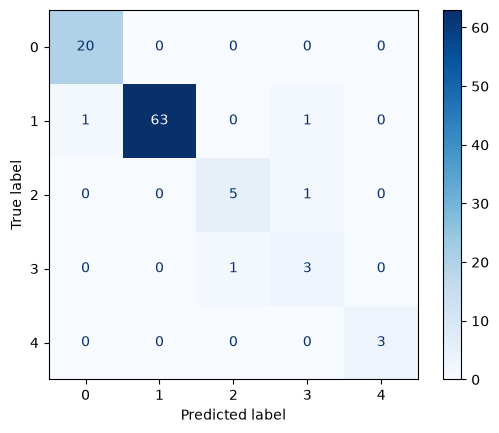

In [66]:
cm = confusion_matrix(y_test, predict)
Image_cm = ConfusionMatrixDisplay(cm)
Image_cm.plot(cmap='Blues')

# ROC AUC

In [67]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [68]:
# predict_proba gives per-class probabilities, shape (n_samples, n_classes)
# this is what roc_auc_score needs for multiclass (predict() only gives hard labels)
predict_proba = random_search_cv.predict_proba(x_test)
print("predict_proba.shape:", predict_proba.shape)

predict_proba.shape: (98, 6)


In [69]:
# Overall multiclass ROC AUC (one-vs-rest, macro-averaged)
roc_auc = roc_auc_score(
    y_test,
    predict_proba,
    multi_class='ovr',
    average='macro',
    labels=random_search_cv.classes_
)
print("Macro ROC AUC:", roc_auc)

Macro ROC AUC: nan


/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


/home/shanta-majumder/DS_env/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1364: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


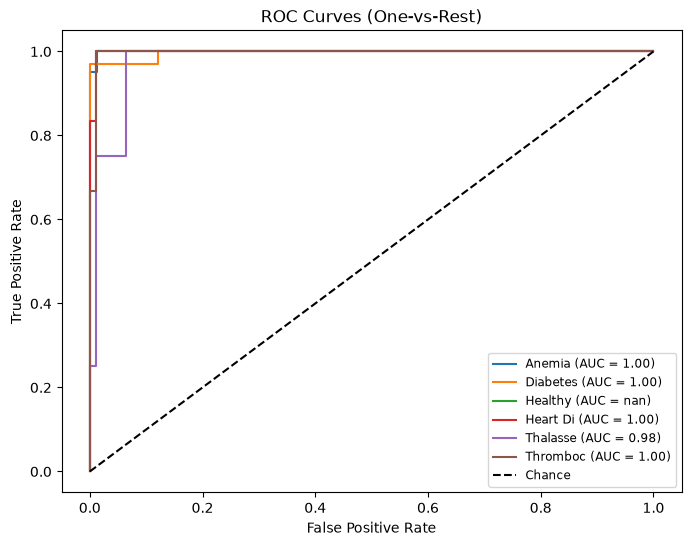

In [70]:
classes = random_search_cv.classes_
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)

fpr = {}
tpr = {}
roc_auc_per_class = {}

for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], predict_proba[:, i])
    roc_auc_per_class[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    label_name = label_encoder.inverse_transform(
        [cls])[0] if 'label_encoder' in globals() else str(cls)
    plt.plot(fpr[i], tpr[i],
             label=f'{label_name} (AUC = {roc_auc_per_class[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right', fontsize='small')
plt.show()

# Save the model

In [ ]:
import joblib

# Real-world feature ranges (min, max) for normalizing raw input → [0, 1]
# The training CSV was already min-max scaled to [0, 1], so we store these
# so that disease_app.py can apply the same transform on raw user values.
FEATURE_RANGES = {
    "Glucose":          (50.0, 300.0),
    "Cholesterol":      (100.0, 400.0),
    "Hemoglobin":       (5.0, 20.0),
    "Platelets":        (50000.0, 500000.0),
    "White Blood Cells": (2000.0, 20000.0),
    "Red Blood Cells":  (2.0, 8.0),
    "Hematocrit":       (20.0, 60.0),
    "Mean Corpuscular Volume": (60.0, 110.0),
    "Mean Corpuscular Hemoglobin": (20.0, 40.0),
    "Mean Corpuscular Hemoglobin Concentration": (28.0, 38.0),
    "Insulin":          (2.0, 300.0),
    "BMI":              (10.0, 50.0),
    "Systolic Blood Pressure": (80.0, 200.0),
    "Diastolic Blood Pressure": (40.0, 130.0),
    "Triglycerides":    (30.0, 500.0),
    "HbA1c":            (3.0, 15.0),
    "LDL Cholesterol":  (30.0, 250.0),
    "HDL Cholesterol":  (15.0, 100.0),
    "ALT":              (5.0, 200.0),
    "AST":              (5.0, 200.0),
    "Heart Rate":       (40.0, 150.0),
    "Creatinine":       (0.3, 5.0),
    "Troponin":         (0.0, 2.0),
    "C-reactive Protein": (0.0, 50.0),
}


bundle = {
    "model": random_search_cv,
    "label_encoder": label_encoder,
    "feature_names": list(X.columns),
    "feature_ranges": FEATURE_RANGES,
}

joblib.dump(bundle, "blood_model.pkl")
print("Saved model bundle with keys:", list(bundle.keys()))
print("Label classes:", label_encoder.classes_)

Saved model bundle with keys: ['model', 'label_encoder', 'feature_names', 'feature_ranges']
Label classes: ['Anemia' 'Diabetes' 'Healthy' 'Heart Di' 'Thalasse' 'Thromboc']
